In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
video_path = "./videos/RL1.mp4"
cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print(f"fps={fps}, frames={frame_count}, size={width}x{height}, duration={frame_count/fps:.1f}s")

fps=60.000654583052075, frames=31043, size=3840x2160, duration=517.4s


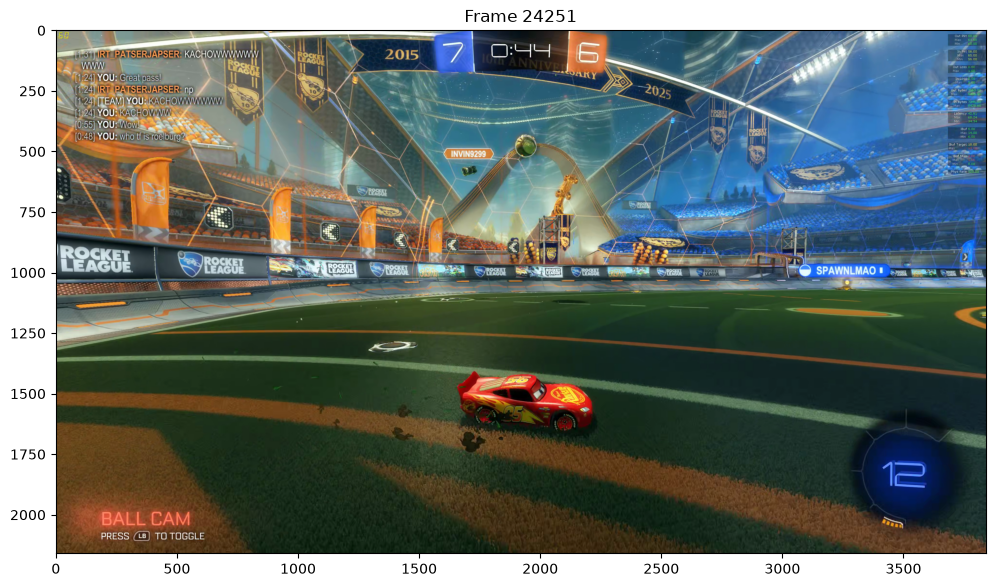

In [3]:
middle_frame_idx = frame_count // 2 + 8730

cap.set(cv2.CAP_PROP_POS_FRAMES, middle_frame_idx)
ret, frame = cap.read()

if not ret:
    raise RuntimeError("Failed to read frame")

# OpenCV loads as BGR, matplotlib wants RGB
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 7))
plt.imshow(frame_rgb)
plt.title(f"Frame {middle_frame_idx}")
plt.axis("on")  # keep axes on so you can read pixel coordinates
plt.show()

In [4]:
cv2.imwrite("middle_frame.png", frame)
print("Saved middle_frame.png")

Saved middle_frame.png


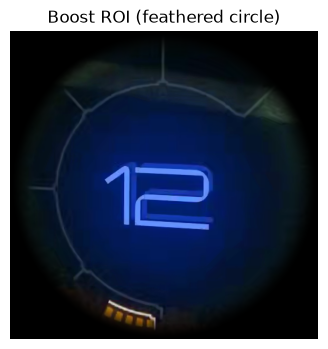

In [5]:
# circle ROI: (center_x, center_y, radius)
boost_roi = (int(width * 0.915), int(height * 0.84), int(min(width, height) * 0.12))

cx, cy, r = boost_roi
x1, y1 = max(cx - r, 0), max(cy - r, 0)
x2, y2 = min(cx + r, width), min(cy + r, height)

boost_region = frame[y1:y2, x1:x2]

# Feather inward from the circle edge; increase for a softer transition.
feather_px = 50  # source pixels; 0 gives a hard edge

yy, xx = np.ogrid[:boost_region.shape[0], :boost_region.shape[1]]
distance = np.hypot(xx - (cx - x1), yy - (cy - y1))
if feather_px > 0:
    alpha = np.clip((r - distance) / feather_px, 0.0, 1.0)
    alpha = alpha * alpha * (3.0 - 2.0 * alpha)  # smoothstep
else:
    alpha = (distance <= r).astype(np.float32)

mask = np.rint(alpha * 255).astype(np.uint8)
# Multiply by alpha: bitwise_and treats all nonzero mask values as opaque.
boost_circular = np.rint(boost_region * alpha[..., None]).astype(np.uint8)

plt.figure(figsize=(6, 4))
plt.imshow(cv2.cvtColor(boost_circular, cv2.COLOR_BGR2RGB))
plt.title("Boost ROI (feathered circle)")
plt.axis("off")
plt.show()

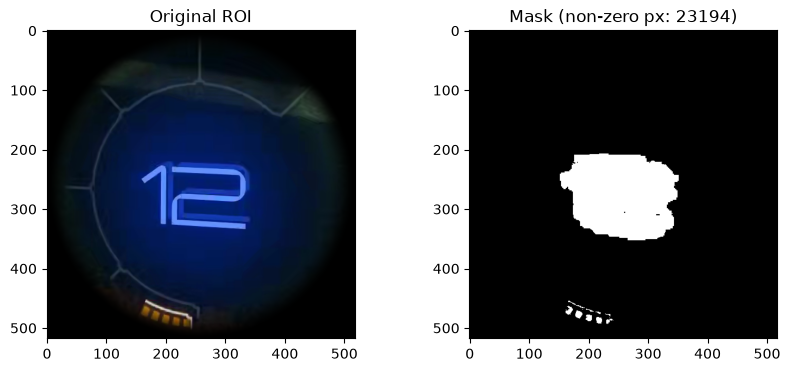

In [6]:
hsv = cv2.cvtColor(boost_circular, cv2.COLOR_BGR2HSV)

# rough starting ranges — you'll want to tune these against real samples
lower_orange = np.array([5, 100, 100])
upper_orange = np.array([20, 255, 255])
lower_blue   = np.array([100, 100, 100])
upper_blue   = np.array([130, 255, 255])
lower_white  = np.array([0, 0, 200])
upper_white  = np.array([180, 30, 255])

color_mask = (
    cv2.inRange(hsv, lower_orange, upper_orange)
    | cv2.inRange(hsv, lower_blue, upper_blue)
    | cv2.inRange(hsv, lower_white, upper_white)
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(cv2.cvtColor(boost_circular, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original ROI")
axes[1].imshow(color_mask, cmap="gray")
axes[1].set_title(f"Mask (non-zero px: {np.count_nonzero(color_mask)})")
plt.show()

Compared frames: [24246, 24247, 24248, 24249, 24250, 24251, 24252, 24253, 24254, 24255, 24256]
Stable pixels: 132575 / 268324


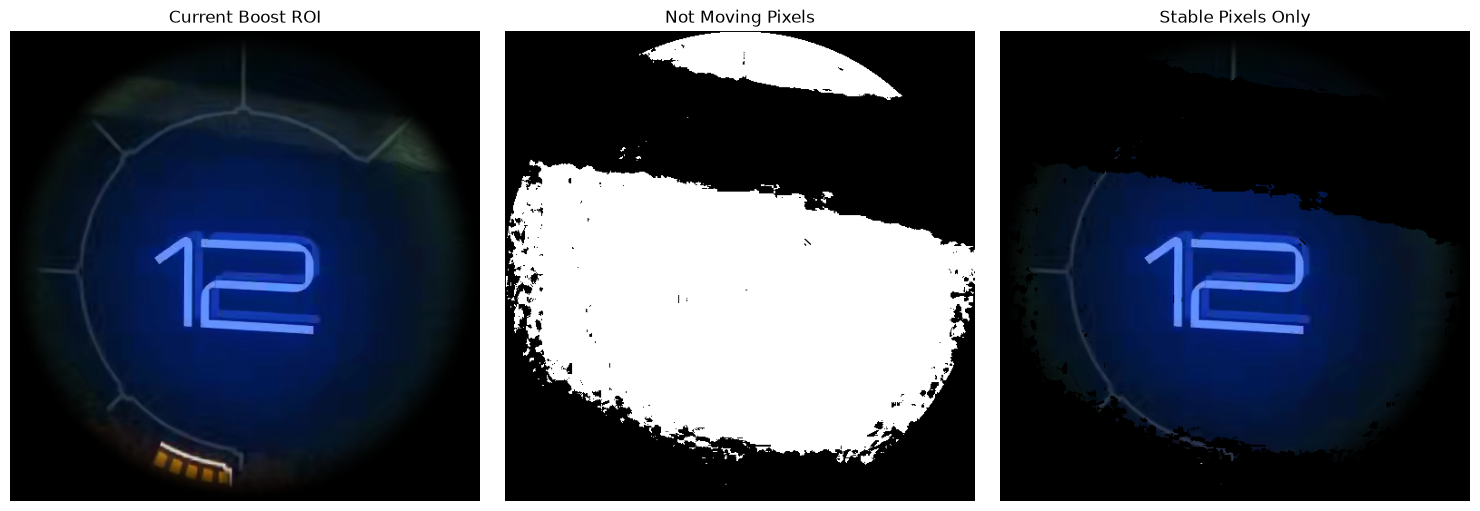

In [7]:
center_idx = middle_frame_idx
offsets = range(-5, 6)

roi_frames = []
used_indices = []

for off in offsets:
    idx = center_idx + off
    if idx < 0 or idx >= frame_count:
        continue

    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, fr = cap.read()
    if not ret:
        continue

    # Reuse the clipped bounds from the circular ROI cell.
    roi = fr[y1:y2, x1:x2]
    roi_gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)

    roi_frames.append(roi_gray)
    used_indices.append(idx)

if len(roi_frames) < 2:
    raise RuntimeError("Not enough frames to compare")

stack = np.stack(roi_frames, axis=0).astype(np.int16)

# pixels with very small variation across the sampled window are treated as not moving
movement_range = stack.max(axis=0) - stack.min(axis=0)
stable_mask = (movement_range <= 8) & (alpha > 0)

stable_pixels = np.zeros_like(boost_circular)
stable_pixels[stable_mask] = boost_circular[stable_mask]

print(f"Compared frames: {used_indices}")
print(f"Stable pixels: {np.count_nonzero(stable_mask)} / {stable_mask.size}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(cv2.cvtColor(boost_circular, cv2.COLOR_BGR2RGB))
axes[0].set_title("Current Boost ROI")
axes[0].axis("off")

axes[1].imshow(stable_mask, cmap="gray")
axes[1].set_title("Not Moving Pixels")
axes[1].axis("off")

axes[2].imshow(cv2.cvtColor(stable_pixels, cv2.COLOR_BGR2RGB))
axes[2].set_title("Stable Pixels Only")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## Feathered boost overlay

Run the notebook from the top. The color and motion masks above are diagnostics; the overlay below uses the current frame's circular boost crop and feathered alpha. Pixels inside the circle retain the source background. Adjust `boost_roi` and `feather_px` in the circle cell to tune the crop.

The following cells preview transparency and place the boost at the bottom right of a portrait frame. They save `boost_overlay.png`, `boost_comparison.png`, and `boost_portrait_preview.png` in `artifacts/`. This is a single-frame preview; regenerate the crop for each frame when processing video so the boost value stays current.


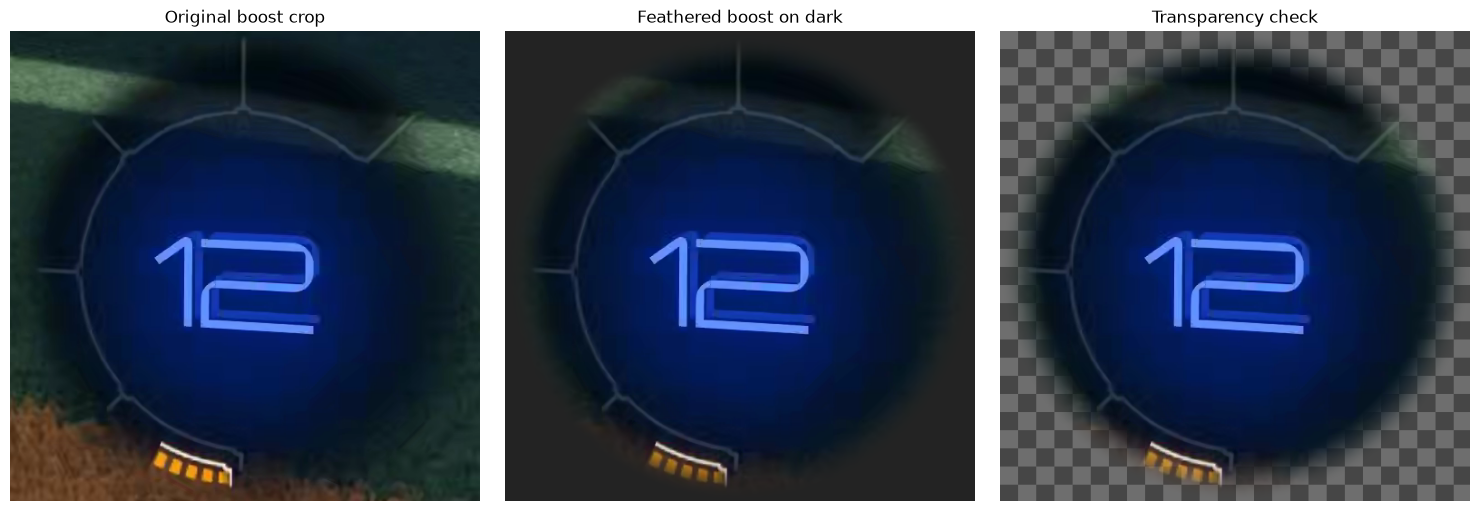

In [8]:
from pathlib import Path
from crop import crop_portrait

# Keep original colors with a separate alpha channel to avoid double feathering.
boost_alpha = np.rint(alpha * 255).astype(np.uint8)
boost_bgra = np.dstack([boost_region, boost_alpha])

def composite_boost(background, overlay):
    opacity = overlay[..., 3:4].astype(np.float32) / 255.0
    return np.rint(
        overlay[..., :3] * opacity + background * (1.0 - opacity)
    ).clip(0, 255).astype(np.uint8)

h, w = boost_bgra.shape[:2]
yy, xx = np.indices((h, w))
checker_gray = np.where((xx // 20 + yy // 20) % 2, 70, 110).astype(np.uint8)
checker = np.repeat(checker_gray[..., None], 3, axis=2)
boost_on_checker = composite_boost(checker, boost_bgra)
boost_on_dark = composite_boost(np.full((h, w, 3), 35, np.uint8), boost_bgra)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, img, title in zip(
    axes,
    [boost_region, boost_on_dark, boost_on_checker],
    ["Original boost crop", "Feathered boost on dark", "Transparency check"],
):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
output_dir = Path("artifacts")
output_dir.mkdir(exist_ok=True)
fig.savefig(output_dir / "boost_comparison.png", dpi=140, bbox_inches="tight")
plt.show()


Boost overlay size: 300x300, position: (726, 1566)


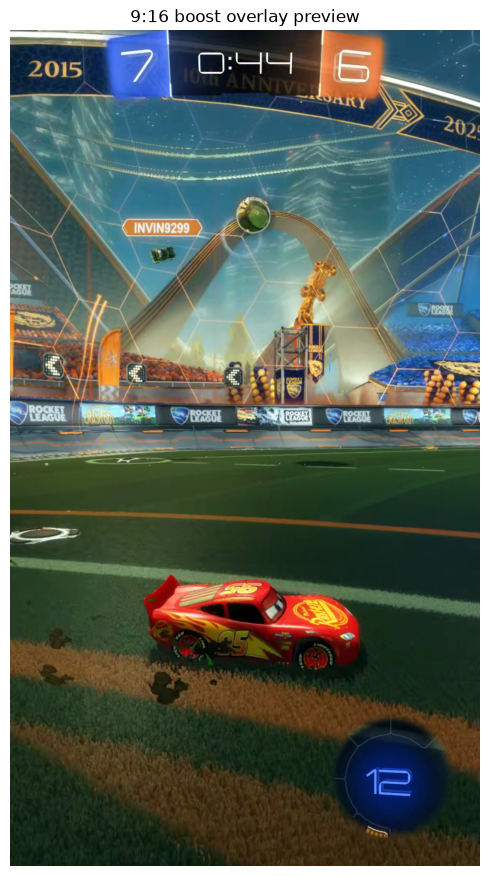

Saved artifacts/boost_overlay.png, boost_comparison.png, and boost_portrait_preview.png


In [9]:
portrait_preview = crop_portrait(frame)
portrait_h, portrait_w = portrait_preview.shape[:2]

# Output-pixel tuning for the boost size and bottom/right margin.
boost_width = 300
margin = 54
boost_height = max(1, round(boost_width * h / w))
if margin < 0 or boost_width <= 0 or boost_width + margin > portrait_w or boost_height + margin > portrait_h:
    raise ValueError("Boost size and margin must fit inside the portrait frame")

resized_boost = cv2.resize(boost_bgra, (boost_width, boost_height), interpolation=cv2.INTER_LINEAR)
left = portrait_w - margin - boost_width
top = portrait_h - margin - boost_height
target = portrait_preview[top:top + boost_height, left:left + boost_width]
portrait_preview[top:top + boost_height, left:left + boost_width] = composite_boost(target, resized_boost)
print(f"Boost overlay size: {boost_width}x{boost_height}, position: ({left}, {top})")

for filename, img in [("boost_overlay.png", boost_bgra),
                      ("boost_portrait_preview.png", portrait_preview)]:
    if not cv2.imwrite(str(output_dir / filename), img):
        raise RuntimeError(f"Could not write {filename}")

plt.figure(figsize=(5, 9))
plt.imshow(cv2.cvtColor(portrait_preview, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("9:16 boost overlay preview")
plt.tight_layout()
plt.show()
print("Saved artifacts/boost_overlay.png, boost_comparison.png, and boost_portrait_preview.png")


(np.float64(-0.5), np.float64(1079.5), np.float64(1919.5), np.float64(-0.5))

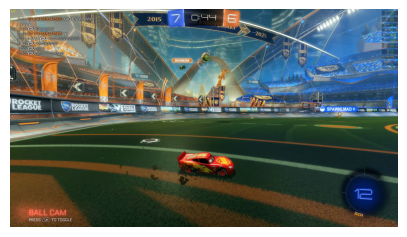

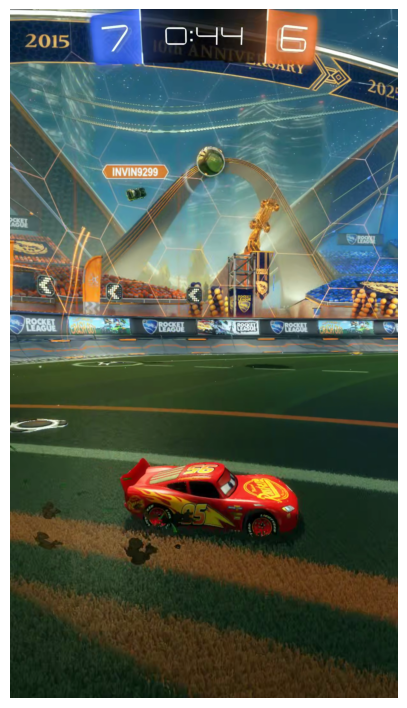

In [10]:
plt.figure(figsize=(5, 9))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.axis("off")


cropped_frame = crop_portrait(frame)

plt.figure(figsize=(5, 9))
plt.imshow(cv2.cvtColor(cropped_frame, cv2.COLOR_BGR2RGB))
plt.axis("off")

(np.float64(-0.5), np.float64(1079.5), np.float64(1919.5), np.float64(-0.5))

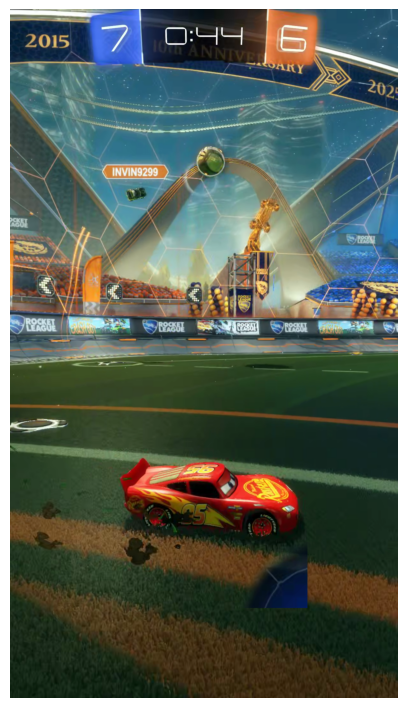

In [11]:
from boost import add_boost

added_boost_frame = add_boost(frame, cropped_frame, new_boost_pos=(726, 1566), new_boost_size=0.4)

plt.figure(figsize=(5, 9))
plt.imshow(cv2.cvtColor(added_boost_frame, cv2.COLOR_BGR2RGB))
plt.axis("off")